# Matplotlib — 15 Visualization Questions

In [14]:
# 1. Monthly Revenue Line Chart
# Using order_date and revenue:
# • Convert order_date to datetime.
# • Calculate total revenue for each month.
# • Create a line chart.
# • Add:
# o Title
# o X-axis label
# o Y-axis label

# o Grid
# o Markers

# Commands/concepts: plt.plot(), plt.title(), plt.xlabel(), plt.ylabel(), plt.grid()


import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("C:\\Users\\Shree\\Downloads\\matplotlib_messy_sales_2000.csv")
df

,Customer ID,Order Date,City,Product Category,Customer Segment,Gender,Sales Channel,Age,Units Sold,Unit Price,Discount %,Customer Rating,Is Active,Returned,Payment Method,Gross Sales,Discount Amount,Revenue,Cost,Profit
0,CUST00594,2025-05-05 00:00:00,Mumbai,Clothing,premium,Male,Retail,36.0,8,24235.73,22.91,1.9,1,0,UPI,193885.84,44419.25,149466.59,88698.45,60768.14
1,CUST01103,2025-10-22 00:00:00,Mumbai,Clothing,Premium,Female,Corporate,38.0,5,16789.55,10.59,4.3,1,0,Cash,83947.75,8890.07,75057.68,61426.31,13631.37
2,CUST00690,2025-04-24 00:00:00,Delhi,Home & Kitchen,Regular,Male,Retail,65.0,2,24579.97,36.22,4.5,1,0,Debit Card,49159.94,17805.73,31354.21,24948.21,6406.00
3,CUST00215,2025-05-17 00:00:00,Chennai,Electronics,Regular,Male,Corporate,34.0,9,6240.13,20.44,3.9,1,0,Net Banking,56161.17,11479.34,NaN,26470.33,18211.50
4,CUST01270,2025-08-30 00:00:00,Delhi,Clothing,Budget,Female,Corporate,41.0,1,23491.23,10.48,3.7,1,0,Net Banking,23491.23,2461.88,21029.35,12312.38,8716.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015,CUST00043,2025-12-17 00:00:00,Pune,Sports,Premium,Male,Retail,24.0,10,9181.27,18.05,3.7,1,0,UPI,91812.70,16572.19,75240.51,39994.75,35245.76
2016,CUST00602,2025-12-22 00:00:00,Pune,Sports,Regular,Female,Retail,44.0,9,6947.94,32.93,1.5,1,0,Cash,62531.46,20591.61,41939.85,33246.33,8693.52
2017,CUST01708,2025-05-28 00:00:00,Hyderabad,Home & Kitchen,Premium,Male,Retail,56.0,5,5393.37,25.19,3.4,1,0,UPI,26966.85,6792.95,20173.90,13654.93,6518.97
2018,CUST00614,2025-08-27 00:00:00,Chennai,Sports,Premium,Male,Online,41.0,7,10803.59,0.5,5.0,1,0,UPI,75625.13,378.13,75247.00,46822.20,28424.80


In [16]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print(df.columns.tolist())

['customer_id', 'order_date', 'city', 'product_category', 'customer_segment', 'gender', 'sales_channel', 'age', 'units_sold', 'unit_price', 'discount_%', 'customer_rating', 'is_active', 'returned', 'payment_method', 'gross_sales', 'discount_amount', 'revenue', 'cost', 'profit']


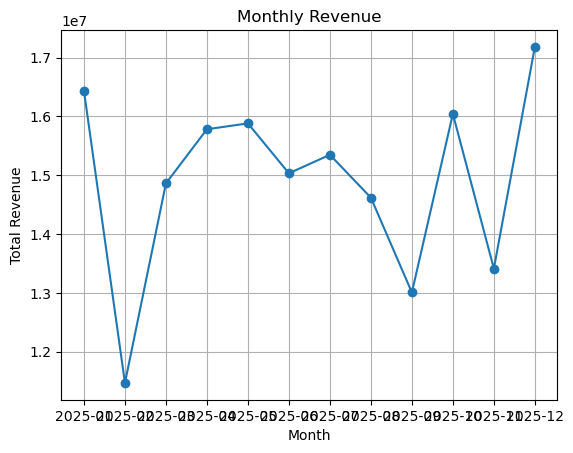

In [18]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

monthly_revenue = df.groupby(
    df["order_date"].dt.to_period("M")
)["revenue"].sum()

months = monthly_revenue.index.astype(str)

plt.plot(months, monthly_revenue.values, marker="o")

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.grid(True)

plt.show()

In [21]:
# 2. Monthly Profit Line Chart
# Create a line chart showing monthly Profit.
# Requirements:
# • Use a different line style.
# • Add markers.
# • Add a legend.
# • Display the value of the highest-profit month using annotate().
# Commands/concepts: plt.plot(), plt.legend(), plt.annotate()



df["order_date"] = pd.to_datetime(df["order_date"],errors = "coerce")
df["order_date"]

0      2025-05-05
1      2025-10-22
2      2025-04-24
3      2025-05-17
4      2025-08-30
          ...    
2015   2025-12-17
2016   2025-12-22
2017   2025-05-28
2018   2025-08-27
2019   2025-12-23
Name: order_date, Length: 2020, dtype: datetime64[ns]

In [23]:
monthly_profit = df.groupby(df["order_date"].dt.to_period("M"))["profit"].sum()
monthly_profit

order_date
2025-01    5256690.78
2025-02    3516340.41
2025-03    4638856.93
2025-04    5219010.06
2025-05    5211112.10
2025-06    4864554.54
2025-07    4749443.78
2025-08    4883550.53
2025-09    4525419.15
2025-10    5249550.39
2025-11    4475543.42
2025-12    5678426.89
Freq: M, Name: profit, dtype: float64

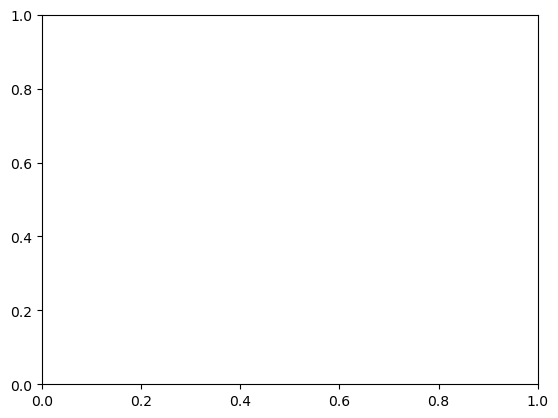

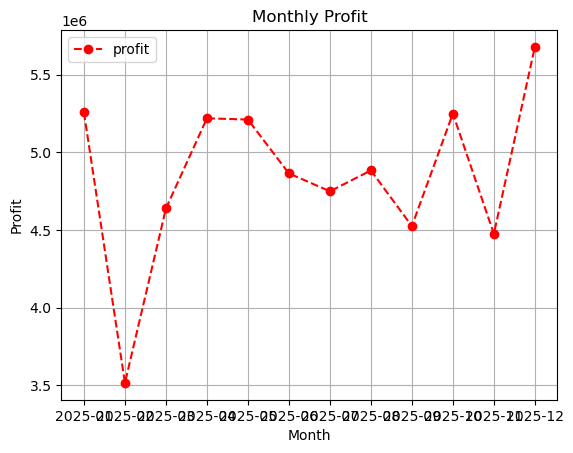

In [31]:
highest = profits.max()
position = profits.argmax()


plt.annotate(
    f"Highest: {highest}",
    xy=(position, highest),
    xytext=(10, 10),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)
plt.show()

plt.plot(monthly_profit.index.astype(str),
         monthly_profit.values,
         "r--o",
         label = "profit")
plt.title("Monthly Profit")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.grid(True)
plt.legend()

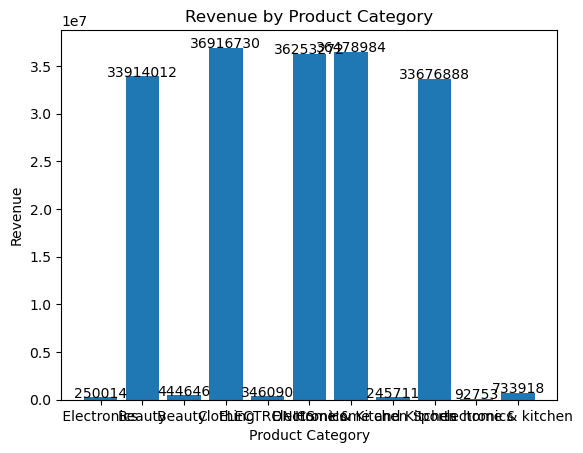

In [36]:
# 3. Revenue by Product Category — Bar Chart
# Calculate total revenue for each product_category.
# Create a bar chart.
# Requirements:
# • X-axis → Product Category
# • Y-axis → Revenue
# • Add title and labels.
# • Display the revenue value above each bar.
# Commands/concepts: plt.bar(), plt.text()



data = df.groupby("product_category")["revenue"].sum()

plt.bar(data.index, data.values)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

for i, v in enumerate(data.values):
    plt.text(i, v, str(round(v)), ha="center")

plt.show()

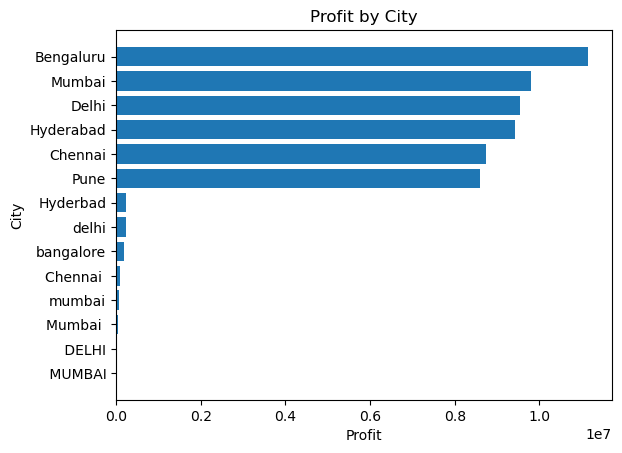

In [37]:
# 4. Profit by City — Horizontal Bar Chart
# Calculate total profit for each city.
# Create a horizontal bar chart.
# Requirements:
# • Sort cities by profit.
# • Show the highest-profit city first.
# • Add title and axis labels.
# Commands/concepts: plt.barh(), sort_values()


data = df.groupby("city")["profit"].sum()

data = data.sort_values(ascending=False)

plt.barh(data.index, data.values)

plt.title("Profit by City")
plt.xlabel("Profit")
plt.ylabel("City")

plt.gca().invert_yaxis()

plt.show()

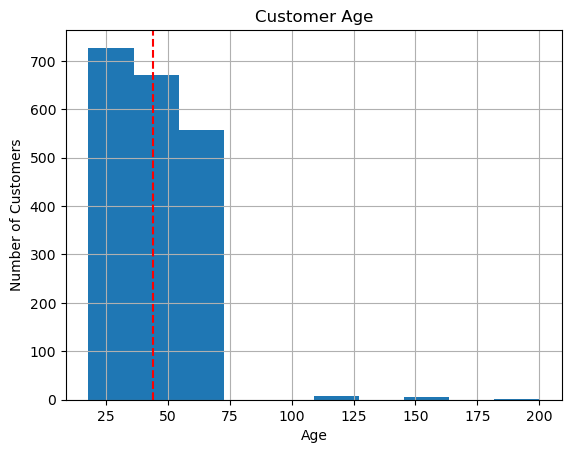

In [40]:
# 5. Customer Age Histogram
# Create a histogram of the age column.
# Requirements:
# • Use 10 bins.
# • Add title.
# • Add X/Y labels.
# • Add grid.
# • Add a vertical line showing the median age.
# Commands/concepts: plt.hist(), plt.axvline()


df["age"] = pd.to_numeric(df["age"], errors="coerce")

median_age = df["age"].median()

plt.hist(df["age"], bins=10)

plt.title("Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.axvline(median_age, color="red", linestyle="--")

plt.grid(True)

plt.show()

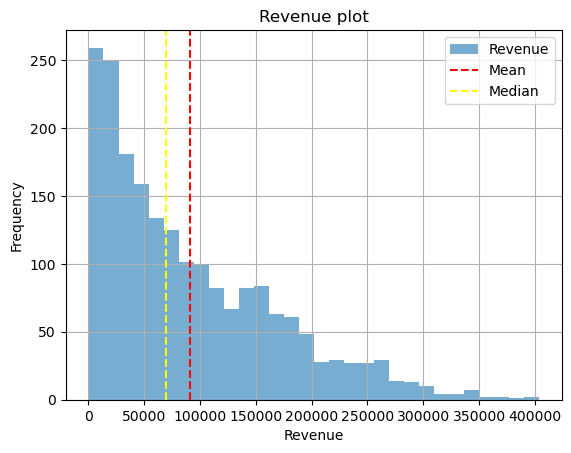

In [41]:
# 6. Revenue Distribution Histogram
# Create a histogram showing the distribution of revenue.
# Requirements:
# • Use 20 bins.
# • Add transparency using alpha.
# • Add grid.
# • Add mean and median lines.
# • Add a legend.
# Commands/concepts:
# plt.hist()
# plt.axvline()
# plt.legend()


mean = df["revenue"].mean()
median = df["revenue"].median()

plt.hist(df["revenue"], bins = 30, alpha = 0.6, label = "Revenue")
plt.axvline(mean, color = "red", linestyle = "--", label = "Mean")
plt.axvline(median, color = "Yellow",linestyle = "--", label = "Median")

plt.title("Revenue plot")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.grid(True)
plt.legend()

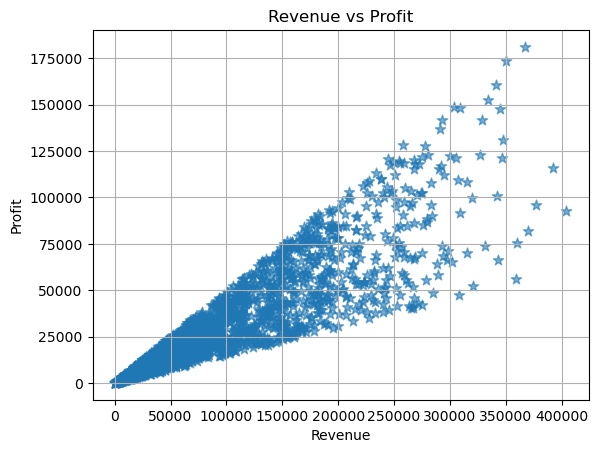

In [42]:
# 7. Revenue vs Profit Scatter Plot
# Create a scatter plot between:
# • X → Revenue
# • Y → Profit
# Requirements:
# • Use different marker size.
# • Add transparency.
# • Add title and axis labels.
# • Add grid.
# Commands/concepts:
# plt.scatter()
# Important parameters to practice:
# s=
# alpha=
# marker=


plt.scatter(df["revenue"],
            df["profit"],
            s=60,
            alpha = 0.6,
            marker = "*")
plt.title("Revenue vs Profit")
plt.xlabel("Revenue")
plt.ylabel("Profit")
plt.grid(True)

plt.show()

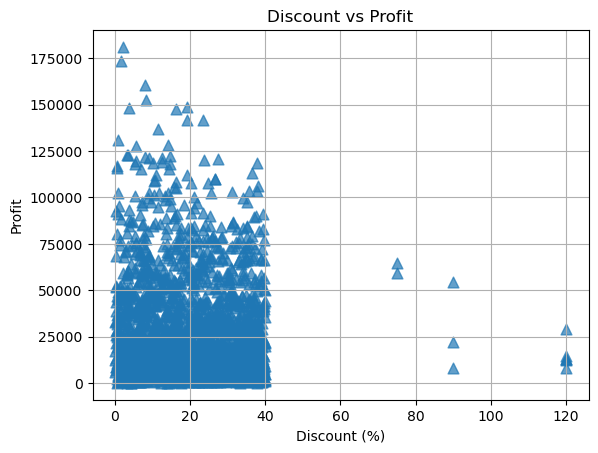

In [54]:
# 8. Discount vs Profit Scatter Plot
# Create a scatter plot between:
# • X → discount_pct
# • Y → profit
# Requirements:
# • Use a different marker.
# • Add transparency.
# • Add title.
# • Add axis labels.
# • Add grid.
# Then answer:
# Does profit appear to decrease as discount increases?


df["discount_%"] = pd.to_numeric(df["discount_%"], errors="coerce")
df["profit"] = pd.to_numeric(df["profit"], errors="coerce")

plt.scatter(
    df["discount_%"],
    df["profit"],
    s=60,
    alpha=0.7,
    marker="^"
)

plt.title("Discount vs Profit")
plt.xlabel("Discount (%)")
plt.ylabel("Profit")
plt.grid(True)

plt.show()

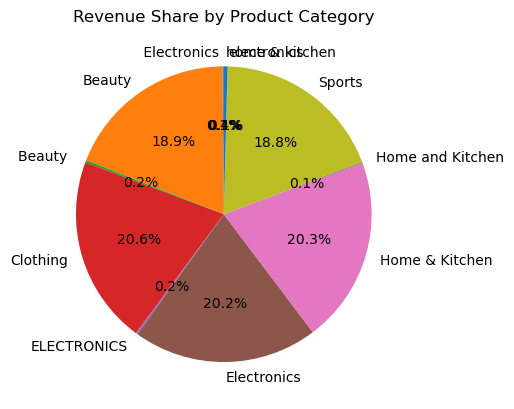

In [56]:
# 9. Revenue Share — Pie Chart
# Calculate total revenue for every product_category.
# Create a pie chart showing each category's contribution.
# Requirements:
# • Display percentages.
# • Display category names.
# • Add a title.
# • Start the first slice from the top.
# Commands/concepts:
# plt.pie()
# Important parameters:
# autopct=
# startangle=
# labels=



data = df.groupby("product_category")["revenue"].sum()

plt.pie(
    data,
    labels=data.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Share by Product Category")

plt.show()

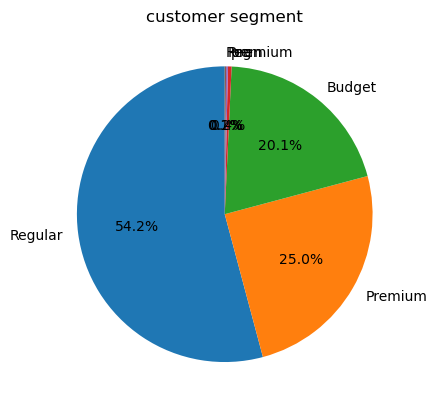

In [59]:
# 10. Customer Segment Pie Chart
# Create a pie chart showing the number of customers/orders in each customer segment.
# Segments:
# • Premium
# • Regular
# • Budget
# Requirements:
# • Show percentage.
# • Add labels.
# • Add title.
# • Make the chart visually clean.
# Question: Which customer segment has the largest share?


data = df["customer_segment"].value_counts()
plt.pie(data,
        labels = data.index,
        autopct = "%1.1f%%",
        startangle = 90)
plt.title("customer segment")
plt.show()

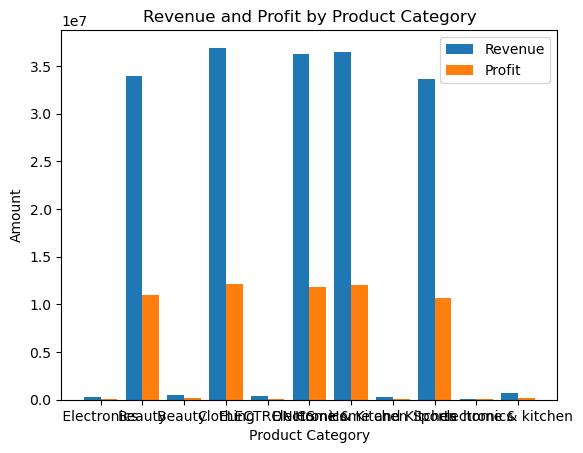

In [60]:
# 11. Compare Revenue and Profit
# Create a grouped bar chart for each product_category.
# For every category show:
# • Revenue
# • Profit
# Requirements:
# • Two bars per category.
# • Different colors.
# • Add legend.
# • Add title and axis labels.
# Concepts: plt.bar(), bar positions, width, plt.xticks()


data = df.groupby("product_category")[["revenue", "profit"]].sum()

x = range(len(data))

plt.bar(x, data["revenue"], width=0.4, label="Revenue")
plt.bar([i + 0.4 for i in x], data["profit"], width=0.4, label="Profit")

plt.xticks([i + 0.2 for i in x], data.index)

plt.title("Revenue and Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Amount")

plt.legend()
plt.show()

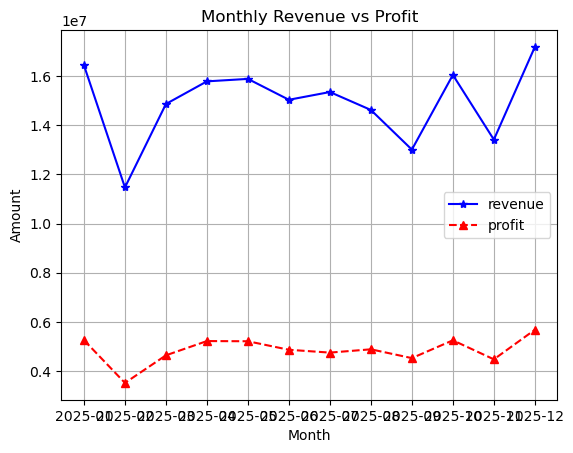

In [63]:
# 12. Monthly Revenue vs Profit
# Create a chart containing two lines:
# • Revenue
# • Profit
# for every month.
# Requirements:
# • Different colors.
# • Different markers.
# • Different line styles.
# • Legend.
# • Grid.
# • Title.
# • X/Y labels.
# Example concept:
# plt.plot(months, revenue)
# plt.plot(months, profit)


df["order_date"] = pd.to_datetime(df["order_date"],errors = "coerce")

monthly = df.groupby(
    df["order_date"].dt.to_period("M")
)[["revenue", "profit"]].sum()

months = monthly.index.astype(str)

plt.plot(months,monthly["revenue"],
         color = "blue",
         marker = "*",
         linestyle = "-",
         label = "revenue")
plt.plot(months,
         monthly["profit"],
         color = "red",
         marker = "^",
         linestyle = "--",
         label = "profit"
        )
plt.title("Monthly Revenue vs Profit")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.grid(True)
plt.legend()
plt.show()

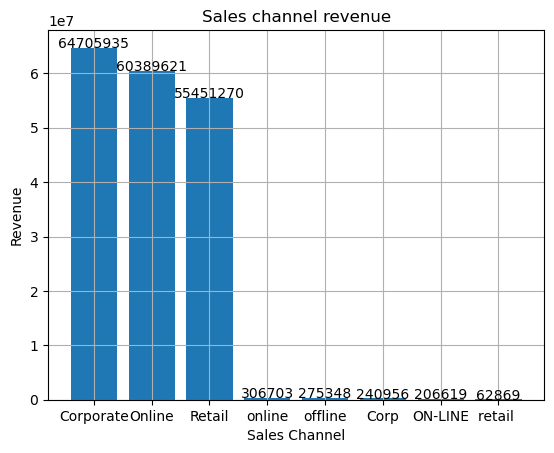

In [64]:
# 13. Sales Channel Comparison
# Calculate total revenue for:
# • Online
# • Retail
# • Corporate
# Create a bar chart.
# Requirements:
# • Add value labels on bars.
# • Sort from highest to lowest.
# • Add title.
# • Add axis labels.
# • Add grid.
# Question: Which sales channel generates the highest revenue?



data = df.groupby("sales_channel")["revenue"].sum()

data = data.sort_values(ascending = False)
plt.bar(data.index,data.values)

for i, v in enumerate(data.values):
    plt.text(i,v,round(v), ha = "center")

plt.title("Sales channel revenue")
plt.xlabel("Sales Channel")
plt.ylabel("Revenue")
plt.grid()
plt.show()

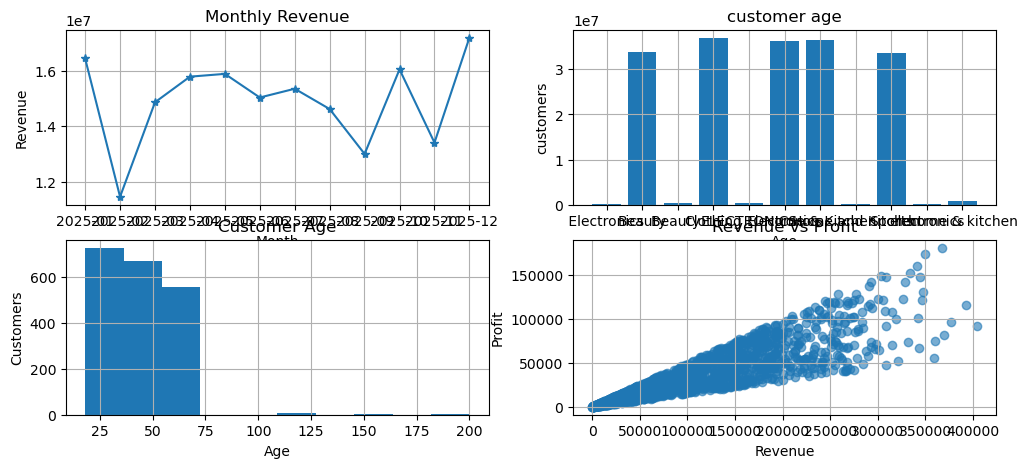

In [70]:
# 14. Four-Chart Matplotlib Dashboard
# Create a 2 × 2 subplot.
# Chart 1
# Monthly Revenue → Line chart
# Chart 2
# Revenue by Category → Bar chart
# Chart 3
# Customer Age → Histogram
# Chart 4
# Revenue vs Profit → Scatter plot
# Use:
# plt.subplots(2, 2)
# Give every subplot:
# • Its own title
# • Appropriate labels
# • Grid where useful
# Finally use:
# plt.tight_layout()


df["order_date"] = pd.to_datetime(df["order_date"],errors = "coerce")

monthly = df.groupby(df["order_date"].dt.to_period("M"))[["revenue","profit"]].sum()

category = df.groupby("product_category")["revenue"].sum()
fig,axes = plt.subplots(2,2,figsize =(12,5))
axes[0,0].plot(monthly.index.astype(str),monthly["revenue"],marker = "*")
axes[0,0].set_title("Monthly Revenue")
axes[0,0].set_xlabel("Month")
axes[0,0].set_ylabel("Revenue")
axes[0,0].grid(True)

axes[0,1].bar(category.index, category.values)
axes[0,1].set_title("customer age")
axes[0,1].set_xlabel("Age")
axes[0,1].set_ylabel("customers")
axes[0,1].grid(True)

axes[1, 0].hist(df["age"], bins=10)
axes[1, 0].set_title("Customer Age")
axes[1, 0].set_xlabel("Age")
axes[1, 0].set_ylabel("Customers")
axes[1, 0].grid(True)

axes[1, 1].scatter(
    df["revenue"],
    df["profit"],
    alpha=0.6
)

axes[1, 1].set_title("Revenue vs Profit")
axes[1, 1].set_xlabel("Revenue")
axes[1, 1].set_ylabel("Profit")
axes[1, 1].grid(True)

plt.show()

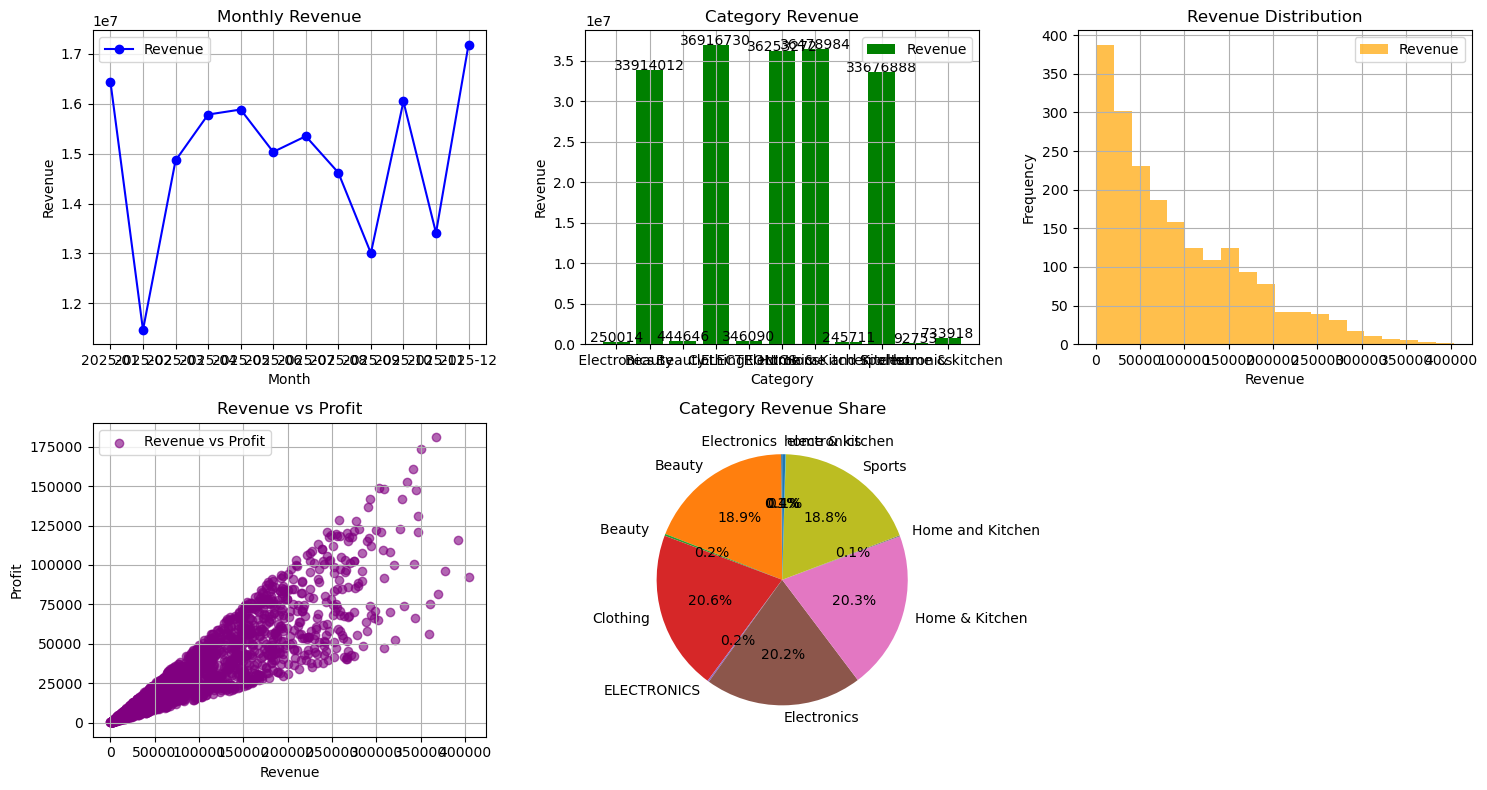

In [76]:
# 15. Final Exam Question — Sales Analysis
# Using the complete dataset, create a professional Matplotlib visualization containing:
# Chart 1: Monthly Revenue → Line chart
# Chart 2: Category Revenue → Bar chart
# Chart 3: Revenue Distribution → Histogram
# Chart 4: Revenue vs Profit → Scatter plot
# Chart 5: Category Revenue Share → Pie chart
# For the visual design:
# • Add appropriate colors
# • Use markers where appropriate
# • Add legends
# • Add grid
# • Add titles



df["order_date"] = pd.to_datetime(df["order_date"],errors = "coerce")
monthly = df.groupby(
    df["order_date"].dt.to_period("M")
)["revenue"].sum()

category = df.groupby("product_category")["revenue"].sum()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0,0].plot(
    monthly.index.astype(str),
    monthly.values,
    color="blue",
    marker="o",
    label="Revenue"
)
axes[0,0].set_title("Monthly Revenue")
axes[0,0].set_xlabel("Month")
axes[0,0].set_ylabel("Revenue")
axes[0,0].grid()
axes[0,0].legend()

bars = axes[0,1].bar(
    category.index,
    category.values,
    color="green",
    label="Revenue"
)
axes[0,1].set_title("Category Revenue")
axes[0,1].set_xlabel("Category")
axes[0,1].set_ylabel("Revenue")
axes[0,1].grid()
axes[0,1].legend()

for bar in bars:
    axes[0,1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        round(bar.get_height()),
        ha="center"
    )

axes[0,2].hist(
    df["revenue"],
    bins=20,
    color="orange",
    alpha=0.7,
    label="Revenue"
)
axes[0,2].set_title("Revenue Distribution")
axes[0,2].set_xlabel("Revenue")
axes[0,2].set_ylabel("Frequency")
axes[0,2].grid()
axes[0,2].legend()

axes[1,0].scatter(
    df["revenue"],
    df["profit"],
    color="purple",
    alpha=0.6,
    marker="o",
    label="Revenue vs Profit"
)

axes[1,0].set_title("Revenue vs Profit")
axes[1,0].set_xlabel("Revenue")
axes[1,0].set_ylabel("Profit")
axes[1,0].grid()
axes[1,0].legend()


axes[1,1].pie(
    category.values,
    labels=category.index,
    autopct="%1.1f%%",
    startangle=90
)
axes[1,1].set_title("Category Revenue Share")

axes[1,2].axis("off")

plt.tight_layout()
plt.show()